In [1]:
import os
import sys
import json
import copy
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup
)

# Import the feature pipeline utilities (for data loading and propagation)
from Rumors_Classifier.feature_pipeline import (
    load_tweets,
    load_propagation_counts,
)

import logging
from datetime import datetime

In [2]:



def setup_logger(name="training", log_dir="logs"):
    os.makedirs(log_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = os.path.join(log_dir, f"training_{timestamp}.log")

    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)

    # Prevent duplicate handlers
    if logger.handlers:
        return logger

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # File handler
    file_handler = logging.FileHandler(log_file)
    file_handler.setFormatter(formatter)

    # Console handler
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)

    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

    return logger

In [3]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths to data (adjust to your local setup)
DATA_ROOT = Path("../../ArCOV19-Rumors/tweet_verification")
TWEETS_PATH = DATA_ROOT / "Tweets.txt"
REPLIES_PATH = DATA_ROOT / "propagation_networks/replies"
RETWEETS_PATH = DATA_ROOT / "propagation_networks/retweets"


Using device: cuda


In [ ]:
tweets_df = load_tweets(TWEETS_PATH)

reply_counts   = load_propagation_counts(REPLIES_PATH)
retweet_counts = load_propagation_counts(RETWEETS_PATH)

tweets_df['num_replies']   = tweets_df['tweetID'].map(reply_counts).fillna(0).astype(int)
tweets_df['num_retweets']  = tweets_df['tweetID'].map(retweet_counts).fillna(0).astype(int)

df = tweets_df[['tweetText', 'label', 'num_replies', 'num_retweets']].copy()

def minimal_preprocess(text):
    return ' '.join(text.split())

df['text'] = df['tweetText'].apply(minimal_preprocess)

df['label'] = df['label'].astype(int)

agg_funcs = {
    'label': 'first',
    'num_replies': 'mean',
    'num_retweets': 'mean',
    'text': 'first'
}

df = df.groupby('tweetText', as_index=False).agg(agg_funcs)

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(df.head())

In [5]:
class MARBERTClassifier:
    def __init__(self, model_name='UBC-NLP/MARBERT', num_labels=2, max_seq_len=128):
        self.model_name = model_name
        self.num_labels = num_labels
        self.max_seq_len = max_seq_len
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        self.model.to(device)

    def tokenize(self, texts, max_len=None):
        if max_len is None:
            max_len = self.max_seq_len
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )

    def forward(self, input_ids, attention_mask):
        return self.model(input_ids=input_ids, attention_mask=attention_mask)

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [7]:
class MARBERTFusionClassifier(nn.Module):
    def __init__(self, model_name, num_labels, num_prop_features=2, dropout_prob=0.3):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        self.bert.classifier = nn.Identity()
        self.hidden_size = self.bert.config.hidden_size
        self.num_prop_features = num_prop_features
        self.dropout = nn.Dropout(dropout_prob)
        self.fusion_layer = nn.Linear(self.hidden_size + num_prop_features, num_labels)

    def forward(self, input_ids, attention_mask, prop_features):
        outputs = self.bert.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        combined = torch.cat([pooled, prop_features], dim=1)
        combined = self.dropout(combined)
        logits = self.fusion_layer(combined)
        return logits

In [8]:
class TweetDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(
            row['text'],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

class FusionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(
            row['text'],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        if 'num_replies_scaled' in self.df.columns:
            replies = row['num_replies_scaled']
        else:
            replies = np.log1p(row['num_replies'])
        if 'num_retweets_scaled' in self.df.columns:
            retweets = row['num_retweets_scaled']
        else:
            retweets = np.log1p(row['num_retweets'])
        prop = torch.tensor([replies, retweets], dtype=torch.float)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'prop_features': prop,
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

In [9]:
def train_epoch(model, dataloader, optimizer, scheduler, loss_fn, logger, fusion=False):
    model.train()
    total_loss = 0
    running_loss = 0
    all_preds, all_labels = [], []

    for batch_idx, batch in enumerate(tqdm(dataloader, desc='Training')):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        if fusion:
            prop_features = batch['prop_features'].to(device)
            logits = model(input_ids, attention_mask, prop_features)
        else:
            logits = model(input_ids, attention_mask).logits

        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        if (batch_idx + 1) % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            logger.info(
                f"Batch {batch_idx+1}/{len(dataloader)} | "
                f"Loss: {running_loss/100:.4f} | LR: {current_lr:.8f}"
            )
            running_loss = 0

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1

def evaluate(model, dataloader, loss_fn, fusion=False, return_preds=False):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            if fusion:
                prop_features = batch['prop_features'].to(device)
                logits = model(input_ids, attention_mask, prop_features)
            else:
                logits = model(input_ids, attention_mask).logits

            loss = loss_fn(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"f1_score: {f1}")
    if return_preds:
        return avg_loss, f1, all_labels, all_preds

    return avg_loss, f1, None, None

In [10]:
def run_experiment(df, config, folds=None, verbose=True):
    """
    config: dict with keys:
        model_name, num_labels, max_seq_len, batch_size, epochs,
        lr_backbone, lr_head, loss_type ('focal' or 'ce'),
        early_stop_metric ('f1' or 'loss'), patience,
        use_propagation (bool),
        test_size (float, default 0.15),
        val_size   (float, default 0.15)
    """
    logger = setup_logger()

    # Extract parameters
    model_name = config['model_name']
    num_labels = config['num_labels']
    max_seq_len = config['max_seq_len']
    batch_size = config['batch_size']
    epochs = config['epochs']
    lr_backbone = config['lr_backbone']
    lr_head = config['lr_head']
    loss_type = config['loss_type']
    early_stop_metric = config['early_stop_metric']
    patience = config['patience']
    use_propagation = config.get('use_propagation', False)
    test_size = config.get('test_size', 0.15)
    val_size = config.get('val_size', 0.15)

    logger.info("=" * 80)
    logger.info("Starting experiment")
    logger.info("=" * 80)
    for key, value in config.items():
        logger.info(f"{key}: {value}")

    from sklearn.model_selection import train_test_split
    df = df.reset_index(drop=True)   # ensure contiguous integer indices

    df['num_replies_log'] = np.log1p(df['num_replies'])
    df['num_retweets_log'] = np.log1p(df['num_retweets'])

    # Split into train_val and test
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df['label'], random_state=42
    )
    # Reset indices of train_val so they are 0..len(train_val)-1
    train_val_df = train_val_df.reset_index(drop=True)

    # If folds is None, create a single train/val split from train_val_df
    if folds is None:
        val_prop = val_size / (1 - test_size)
        train_df, val_df = train_test_split(
            train_val_df, test_size=val_prop,
            stratify=train_val_df['label'], random_state=42
        )
        # Create a single fold (indices refer to train_val_df)
        folds = [(list(train_df.index), list(val_df.index))]
        logger.info("Using single train/val/test split (no cross validation).")
    else:
        orig_to_new = {orig_idx: new_idx for new_idx, orig_idx in enumerate(train_val_df.index)}
        remapped_folds = []
        for train_idx, val_idx in folds:
            # Convert to new indices, skipping any that belong to test set
            new_train = [orig_to_new[i] for i in train_idx if i in orig_to_new]
            new_val   = [orig_to_new[i] for i in val_idx   if i in orig_to_new]
            if len(new_train) == 0 or len(new_val) == 0:
                raise ValueError("A fold contains only test indices – check your splits.")
            remapped_folds.append((new_train, new_val))
        folds = remapped_folds
        logger.info(f"Using {len(folds)} fold cross validation (test set held out).")

    val_f1_scores = []
    test_f1_scores = []
    test_labels = None
    test_preds = None

    for fold, (train_idx, val_idx) in enumerate(folds):
        if verbose:
            logger.info(
                f"{'='*60}\n"
                f"Fold {fold+1}/{len(folds)}\n"
                f"Train samples: {len(train_idx)} | "
                f"Validation samples: {len(val_idx)}"
            )
        train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

        if use_propagation:
            scaler = StandardScaler()

            # Extract the log-transformed training features
            train_log_features = train_df[['num_replies_log', 'num_retweets_log']].values

            # FIT the scaler ONLY on the training fold
            scaler.fit(train_log_features)

            # Transform training set
            scaled_train = scaler.transform(train_log_features)
            train_df['num_replies_scaled'] = scaled_train[:, 0]
            train_df['num_retweets_scaled'] = scaled_train[:, 1]

            # Transform VALIDATION set using the TRAINING scaler
            val_log_features = val_df[['num_replies_log', 'num_retweets_log']].values
            scaled_val = scaler.transform(val_log_features)
            val_df['num_replies_scaled'] = scaled_val[:, 0]
            val_df['num_retweets_scaled'] = scaled_val[:, 1]

            # 6. Transform the global HELD-OUT TEST set using the TRAINING scaler
            #    Create a fresh copy to avoid mutating the original test_df across folds
            test_log_features = test_df[['num_replies_log', 'num_retweets_log']].values
            scaled_test = scaler.transform(test_log_features)
            # We store these in a temporary variable to pass to the test dataset later
            test_df_scaled = test_df.copy()
            test_df_scaled['num_replies_scaled'] = scaled_test[:, 0]
            test_df_scaled['num_retweets_scaled'] = scaled_test[:, 1]


        # Initialize model
        if use_propagation:
            model = MARBERTFusionClassifier(model_name, num_labels, num_prop_features=2)
            model.to(device)
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            dataset_class = FusionDataset
        else:
            classifier = MARBERTClassifier(model_name, num_labels, max_seq_len)
            model = classifier.model
            tokenizer = classifier.tokenizer
            dataset_class = TweetDataset

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        logger.info(f"Model: {model.__class__.__name__} | Total: {total_params:,} | Trainable: {trainable_params:,}")

        # DataLoaders for train/val
        train_dataset = dataset_class(train_df, tokenizer, max_seq_len)
        val_dataset = dataset_class(val_df, tokenizer, max_seq_len)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Optimizer & scheduler
        if use_propagation:
            head_params = [p for n, p in model.named_parameters() if 'fusion_layer' in n]
            backbone_params = [p for n, p in model.named_parameters() if 'fusion_layer' not in n]
        else:
            head_params = [p for n, p in model.named_parameters() if 'classifier' in n or 'score' in n]
            backbone_params = [p for n, p in model.named_parameters() if not ('classifier' in n or 'score' in n)]

        optimizer_grouped = [
            {'params': backbone_params, 'lr': lr_backbone},
            {'params': head_params, 'lr': lr_head}
        ]
        optimizer = AdamW(optimizer_grouped, weight_decay=0.01)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=0.1*total_steps, num_training_steps=total_steps
        )

        # Loss
        if loss_type == 'focal':
            loss_fn = FocalLoss(gamma=2.0, alpha=None)
        else:
            class_counts = train_df['label'].value_counts().sort_index().values
            class_weights = 1.0 / class_counts
            class_weights = class_weights / class_weights.sum() * len(class_counts)
            alpha = torch.tensor(class_weights, dtype=torch.float).to(device)
            loss_fn = nn.CrossEntropyLoss(weight=alpha)

        # Training loop with early stopping
        best_score = -np.inf if early_stop_metric == 'f1' else np.inf
        best_model_state = None
        patience_counter = 0

        for epoch in range(epochs):
            if verbose:
                logger.info(f"Epoch {epoch+1}/{epochs}")
            train_loss, train_f1 = train_epoch(
                model, train_loader, optimizer, scheduler, loss_fn, logger, fusion=use_propagation
            )
            val_loss, val_f1, _, _ = evaluate(
                model, val_loader, loss_fn, fusion=use_propagation
            )
            if verbose:
                logger.info(
                    f"Epoch {epoch+1}/{epochs} | Train Loss={train_loss:.4f} Train F1={train_f1:.4f} | "
                    f"Val Loss={val_loss:.4f} Val F1={val_f1:.4f}"
                )

            if early_stop_metric == 'f1':
                if val_f1 > best_score:
                    best_score = val_f1
                    best_model_state = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    logger.info(f"New best val F1: {val_f1:.4f}")
                else:
                    patience_counter += 1
            else:
                if val_loss < best_score:
                    best_score = val_loss
                    best_model_state = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    logger.info(f"New best val loss: {val_loss:.4f}")
                else:
                    patience_counter += 1

            if patience_counter >= patience:
                if verbose:
                    logger.warning(f"Early stopping at epoch {epoch+1}.")
                break

        # Restore best model
        if best_model_state is not None:
            print("loading best model")
            model.load_state_dict(best_model_state)

        _, best_val_f1, labels, preds = evaluate(
            model, val_loader, loss_fn, fusion=use_propagation, return_preds=True
        )
        val_f1_scores.append(best_val_f1)

        if use_propagation:
            test_dataset = FusionDataset(test_df_scaled, tokenizer, max_seq_len)
        else:
            test_dataset = dataset_class(test_df, tokenizer, max_seq_len)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        test_loss, test_f1, test_labels, test_preds = evaluate(
            model, test_loader, loss_fn, fusion=use_propagation, return_preds=True
        )
        test_f1_scores.append(test_f1)
        logger.info(f"Fold {fold+1} Test F1: {test_f1:.4f}")

    avg_test_f1 = np.mean(test_f1_scores)
    std_test_f1 = np.std(test_f1_scores)

    if verbose:
        logger.info("=" * 80)
        logger.info(f"Cross validation mean validation F1: {np.mean(val_f1_scores):.4f} ± {np.std(val_f1_scores):.4f}")
        logger.info(f"Final Test F1 (averaged over folds): {avg_test_f1:.4f} ± {std_test_f1:.4f}")
        if test_labels is not None and test_preds is not None:
            report = classification_report(test_labels, test_preds, digits=4)
            logger.info("\nClassification Report (on test set):\n" + report)
        logger.info("=" * 80)

    if folds is None:
        return val_f1_scores[0], test_f1_scores[0]
    else:
        return avg_test_f1, std_test_f1

In [11]:
Differential_CONFIG = {
    'model_name': 'UBC-NLP/MARBERT',
    'num_labels': 2,
    'max_seq_len': 128,
    'batch_size': 32,
    'epochs': 25,
    'lr_backbone': 2e-5,
    'lr_head': 5e-5,
    'loss_type': 'focal',
    'early_stop_metric': 'f1',
    'patience': 2,
    'use_propagation': False
}

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
five_folds = list(skf.split(df, df['label']))
skf_three = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
three_folds = list(skf_three.split(df, df['label']))

In [17]:
# Baseline
config_diff = Differential_CONFIG.copy()
config_diff['lr_backbone'] = 2e-5
config_diff['lr_head'] = 5e-5

# Counterpart
config_same = Differential_CONFIG.copy()
config_same['lr_backbone'] = 5e-5
config_same['lr_head'] = 5e-5

print("=== Differential LR ===")
avg_f1_diff, std_f1_diff = run_experiment(df, config_diff, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_diff:.4f} ± {std_f1_diff:.4f}")

print("\n=== Same LR ===")
avg_f1_same, std_f1_same = run_experiment(df, config_same, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_same:.4f} ± {std_f1_same:.4f}")

print(f"\nImprovement: {avg_f1_diff - avg_f1_same:.4f} F1")

=== Differential LR (baseline) ===


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Result: 0.9634 ± 0.0081

Improvement: 0.0017 F1


In [18]:
config_focal = Differential_CONFIG.copy()
config_focal['loss_type'] = 'focal'

config_ce = Differential_CONFIG.copy()
config_ce['loss_type'] = 'ce'

print("=== Focal Loss ===")
avg_f1_focal, std_f1_focal = run_experiment(df, config_focal, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_focal:.4f} ± {std_f1_focal:.4f}")

print("\n=== Weighted CE ===")
avg_f1_ce, std_f1_ce = run_experiment(df, config_ce, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_ce:.4f} ± {std_f1_ce:.4f}")

print(f"\nImprovement: {avg_f1_focal - avg_f1_ce:.4f} F1")

=== Focal Loss (baseline) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Result: 0.9623 ± 0.0098

Improvement: -0.0003 F1


In [19]:
config_128 = Differential_CONFIG.copy()
config_128['max_seq_len'] = 128

config_512 = Differential_CONFIG.copy()
config_512['max_seq_len'] = 512
config_512['batch_size'] = 8

print("=== max_seq_len=128 ===")
avg_f1_128, std_f1_128 = run_experiment(df, config_128, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_128:.4f} ± {std_f1_128:.4f}")

print("\n=== max_seq_len=512 ===")
avg_f1_512, std_f1_512 = run_experiment(df, config_512, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_512:.4f} ± {std_f1_512:.4f}")

print(f"\nImprovement: {avg_f1_128 - avg_f1_512:.4f} F1")

=== max_seq_len=128 (baseline) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/90 [00:00<?, ?it/s]

Training:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/90 [00:00<?, ?it/s]

Result: 0.9617 ± 0.0064

Improvement: 0.0011 F1


In [20]:
config_f1_es = Differential_CONFIG.copy()
config_f1_es['early_stop_metric'] = 'f1'

config_loss_es = Differential_CONFIG.copy()
config_loss_es['early_stop_metric'] = 'loss'

print("=== ES on F1 ===")
avg_f1_f1es, std_f1_f1es = run_experiment(df, config_f1_es, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_f1es:.4f} ± {std_f1_f1es:.4f}")

print("\n=== ES on loss ===")
avg_f1_losses, std_f1_losses = run_experiment(df, config_loss_es, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_losses:.4f} ± {std_f1_losses:.4f}")

print(f"\nImprovement: {avg_f1_f1es - avg_f1_losses:.4f} F1")

=== ES on F1 (baseline) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Result: 0.9573 ± 0.0066

Improvement: 0.0092 F1


In [23]:
config_five = Differential_CONFIG.copy()
config_three = Differential_CONFIG.copy()

print("=== Five Folds ===")
avg_f1_five, std_f1_five = run_experiment(df, config_five, folds=five_folds, verbose=False)
print(f"Result: {avg_f1_five:.4f} ± {std_f1_five:.4f}")

print("\n=== Three Folds ===")
avg_f1_three, std_f1_three = run_experiment(df, config_three, folds=three_folds, verbose=False)
print(f"Result: {avg_f1_three:.4f} ± {std_f1_three:.4f}")

print(f"\nImprovement: {avg_f1_five - avg_f1_three:.4f} F1")

=== Five Folds ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]

Training:   0%|          | 0/90 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Training:   0%|          | 0/75 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Result: 0.9634 ± 0.0052

Improvement: -0.0014 F1


In [13]:
config_text = Differential_CONFIG.copy()
config_text['use_propagation'] = False

config_fusion = Differential_CONFIG.copy()
config_fusion['use_propagation'] = True

print("=== Text-only ===")
avg_f1_text, std_f1_text = run_experiment(df, config_text, folds=three_folds, verbose=True)
print(f"Result: {avg_f1_text:.4f} ± {std_f1_text:.4f}")

print("\n=== Hybrid fusion ===")
avg_f1_fusion, std_f1_fusion = run_experiment(df, config_fusion, folds=three_folds, verbose=True)
print(f"Result: {avg_f1_fusion:.4f} ± {std_f1_fusion:.4f}")

print(f"\nImprovement: {avg_f1_fusion - avg_f1_text:.4f} F1")

2026-07-07 05:29:09 | INFO | ================================================================================
2026-07-07 05:29:09 | INFO | Starting experiment
2026-07-07 05:29:09 | INFO | ================================================================================
2026-07-07 05:29:09 | INFO | model_name: UBC-NLP/MARBERT
2026-07-07 05:29:09 | INFO | num_labels: 2
2026-07-07 05:29:09 | INFO | max_seq_len: 128
2026-07-07 05:29:09 | INFO | batch_size: 32
2026-07-07 05:29:09 | INFO | epochs: 25
2026-07-07 05:29:09 | INFO | lr_backbone: 2e-05
2026-07-07 05:29:09 | INFO | lr_head: 5e-05
2026-07-07 05:29:09 | INFO | loss_type: focal
2026-07-07 05:29:09 | INFO | early_stop_metric: f1
2026-07-07 05:29:09 | INFO | patience: 2
2026-07-07 05:29:09 | INFO | use_propagation: False
2026-07-07 05:29:09 | INFO | ============================================================
Fold 1/3
Train samples: 2389 | Validation samples: 1195


=== Text-only ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-07-07 05:29:12 | INFO | Model initialized: BertForSequenceClassification
2026-07-07 05:29:12 | INFO | Total parameters: 162,842,882
2026-07-07 05:29:12 | INFO | Trainable parameters: 162,842,882
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2026-07-07 05:29:12 | INFO | Epoch 1/25


Training:   0%|          | 0/75 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

2026-07-07 06:42:54 | INFO | Epoch 9/25 Results | Train Loss=0.0001 | Train F1=1.0000 | Val Loss=0.0783 | Val F1=0.9572
2026-07-07 06:42:54 | WARNING | Early stopping triggered at epoch 9. No improvement for 2 epochs.


Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid va

Result: nan ± nan

Improvement: nan F1


In [16]:
def grid_search_lr(df, base_config, backbone_lrs, head_lr_ratio=10, verbose=True):
    """
    Sweep over backbone learning rates, keeping head_lr = head_lr_ratio * backbone_lr.
    Returns a dict of {backbone_lr: (val_f1, test_f1)} and plots the validation curve.
    """
    results = {}
    val_f1s = []
    lr_list = []

    for lr_backbone in backbone_lrs:
        config = base_config.copy()
        config['lr_backbone'] = lr_backbone
        config['lr_head'] = lr_backbone * head_lr_ratio
        config['test_size'] = 0.15
        config['val_size'] = 0.15

        if verbose:
            print(f"\n--- Running with lr_backbone = {lr_backbone:.2e}, lr_head = {config['lr_head']:.2e} ---")

        val_f1, test_f1 = run_experiment(df, config, folds=None, verbose=verbose)
        results[lr_backbone] = (val_f1, test_f1)
        val_f1s.append(val_f1)
        lr_list.append(lr_backbone)

    # Plotting
    plt.figure(figsize=(8,5))
    plt.semilogx(lr_list, val_f1s, marker='o', linestyle='-', color='b')
    plt.xlabel('Backbone Learning Rate (log scale)')
    plt.ylabel('Validation F1 (macro)')
    plt.title('Learning Rate Sweep - Validation F1')
    plt.grid(True, which='both', linestyle='--', alpha=0.6)

    best_idx = np.argmax(val_f1s)
    plt.axvline(x=lr_list[best_idx], color='r', linestyle='--', label=f'Best LR = {lr_list[best_idx]:.2e}')
    plt.legend()
    plt.show()

    return results

2026-07-07 09:19:55 | INFO | ================================================================================
2026-07-07 09:19:55 | INFO | Starting experiment
2026-07-07 09:19:55 | INFO | ================================================================================
2026-07-07 09:19:55 | INFO | model_name: UBC-NLP/MARBERT
2026-07-07 09:19:55 | INFO | num_labels: 2
2026-07-07 09:19:55 | INFO | max_seq_len: 128
2026-07-07 09:19:55 | INFO | batch_size: 16
2026-07-07 09:19:55 | INFO | epochs: 10
2026-07-07 09:19:55 | INFO | lr_backbone: 1e-06
2026-07-07 09:19:55 | INFO | lr_head: 9.999999999999999e-06
2026-07-07 09:19:55 | INFO | loss_type: focal
2026-07-07 09:19:55 | INFO | early_stop_metric: f1
2026-07-07 09:19:55 | INFO | patience: 3
2026-07-07 09:19:55 | INFO | use_propagation: True
2026-07-07 09:19:55 | INFO | test_size: 0.15
2026-07-07 09:19:55 | INFO | val_size: 0.15
2026-07-07 09:19:55 | INFO | Using single train/val/test split (no cross validation).
2026-07-07 09:19:55 | INFO | 


--- Running with lr_backbone = 1.00e-06, lr_head = 1.00e-05 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2026-07-07 09:19:56 | INFO | Model: MARBERTFusionClassifier | Total: 162,842,886 | Trainable: 162,842,886
C:\Users\LENOVO\Personal Projects\NLP\arabic_rumor_scanner\ARS_venv\Lib\site-packages\transformers\optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2026-07-07 09:19:56 | INFO | Epoch 1/10


Training:   0%|          | 0/157 [00:00<?, ?it/s]

2026-07-07 09:20:40 | INFO | Batch 100/157 | Loss: 0.1749 | LR: 0.00000064


...

Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

f1_score: 0.5909367396593674


Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

2026-07-07 10:38:48 | INFO | Fold 1 Test F1: 0.5409
2026-07-07 10:38:48 | INFO | ================================================================================
2026-07-07 10:38:48 | INFO | Cross validation mean validation F1: 0.5909 ± 0.0000
2026-07-07 10:38:48 | INFO | Final Test F1 (averaged over folds): 0.5409 ± 0.0000
2026-07-07 10:38:48 | INFO | 
Classification Report (on test set):
              precision    recall  f1-score   support

           0     0.5292    0.5513    0.5400       263
           1     0.5530    0.5309    0.5417       275

    accuracy                         0.5409       538
   macro avg     0.5411    0.5411    0.5409       538
weighted avg     0.5414    0.5409    0.5409       538

2026-07-07 10:38:48 | INFO | ================================================================================


f1_score: 0.5408906071316286


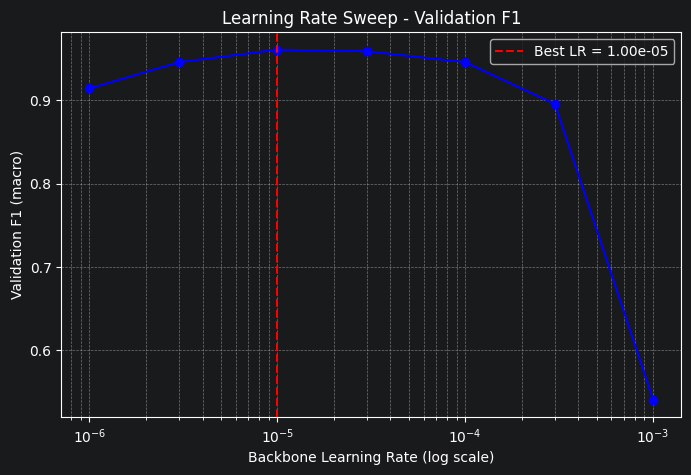


Learning Rate Sweep Results
Backbone LR  Head LR      Val F1     Test F1   
------------------------------------------------------------
1.00e-06    1.00e-05    0.9145      0.0000
3.00e-06    3.00e-05    0.9461      0.0000
1.00e-05    1.00e-04    0.9610      0.0000
3.00e-05    3.00e-04    0.9591      0.0000
1.00e-04    1.00e-03    0.9460      0.0000
3.00e-04    3.00e-03    0.8959      0.0000
1.00e-03    1.00e-02    0.5409      0.0000

Best backbone LR: 1.00e-05 (head LR: 1.00e-04)
Validation F1: 0.9610
Test F1:       0.0000


In [24]:
base_config = {
    'model_name': 'UBC-NLP/MARBERT',
    'num_labels': 2,
    'max_seq_len': 128,
    'batch_size': 16,
    'epochs': 10,
    'lr_backbone': 2e-5,
    'lr_head': 2e-4,
    'loss_type': 'focal',
    'early_stop_metric': 'f1',
    'patience': 3,
    'use_propagation': True,
    'test_size': 0.15,
    'val_size': 0.15
}

# Define a logarithmic range of backbone LRs
backbone_lrs = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]

results = grid_search_lr(df, base_config, backbone_lrs, head_lr_ratio=10, verbose=True)

print("\n" + "="*60)
print("Learning Rate Sweep Results")
print("="*60)
print(f"{'Backbone LR':<12} {'Head LR':<12} {'Val F1':<10} {'Test F1':<10}")
print("-"*60)
for lr, (val_f1, test_f1) in sorted(results.items()):
    head_lr = lr * 10
    print(f"{lr:.2e}    {head_lr:.2e}    {val_f1:.4f}      {test_f1:.4f}")

best_lr = max(results, key=lambda k: results[k][0])
best_val_f1, best_test_f1 = results[best_lr]
print("\n" + "="*60)
print(f"Best backbone LR: {best_lr:.2e} (head LR: {best_lr*10:.2e})")
print(f"Validation F1: {best_val_f1:.4f}")
print(f"Test F1:       {best_test_f1:.4f}")
print("="*60)

In [12]:
final_config = {
    'model_name': 'UBC-NLP/MARBERT',
    'num_labels': 2,
    'max_seq_len': 128,
    'batch_size': 16,
    'epochs': 15,
    'lr_backbone': 1e-5,
    'lr_head': 1e-4,
    'loss_type': 'focal',
    'early_stop_metric': 'f1',
    'patience': 2,
    'use_propagation': True,
    'test_size': 0.15,
    'val_size': 0.15
}

In [12]:
val_f1, test_f1 = run_experiment(df, final_config, folds=None, verbose=True)


2026-07-08 00:15:52 | INFO | ================================================================================
2026-07-08 00:15:52 | INFO | Starting experiment
2026-07-08 00:15:52 | INFO | ================================================================================
2026-07-08 00:15:52 | INFO | model_name: UBC-NLP/MARBERT
2026-07-08 00:15:52 | INFO | num_labels: 2
2026-07-08 00:15:52 | INFO | max_seq_len: 128
2026-07-08 00:15:52 | INFO | batch_size: 16
2026-07-08 00:15:52 | INFO | epochs: 15
2026-07-08 00:15:52 | INFO | lr_backbone: 1e-05
2026-07-08 00:15:52 | INFO | lr_head: 0.0001
2026-07-08 00:15:52 | INFO | loss_type: focal
2026-07-08 00:15:52 | INFO | early_stop_metric: f1
2026-07-08 00:15:52 | INFO | patience: 2
2026-07-08 00:15:52 | INFO | use_propagation: True
2026-07-08 00:15:52 | INFO | test_size: 0.15
2026-07-08 00:15:52 | INFO | val_size: 0.15
2026-07-08 00:15:52 | INFO | Using single train/val/test split (no cross validation).
2026-07-08 00:15:52 | INFO | ===============

Training:   0%|          | 0/152 [00:00<?, ?it/s]

2026-07-08 00:16:17 | INFO | Batch 100/152 | Loss: 0.1679 | LR: 0.00000439


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

2026-07-08 00:16:31 | INFO | Epoch 1/15 | Train Loss=0.1476 Train F1=0.6601 | Val Loss=0.0838 Val F1=0.8441
2026-07-08 00:16:31 | INFO | New best val F1: 0.8441
2026-07-08 00:16:31 | INFO | Epoch 2/15


...

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

f1_score: 0.9615179681487183


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

2026-07-08 00:20:27 | INFO | Fold 1 Test F1: 0.9423
2026-07-08 00:20:27 | INFO | ================================================================================
2026-07-08 00:20:27 | INFO | Cross validation mean validation F1: 0.9615 ± 0.0000
2026-07-08 00:20:27 | INFO | Final Test F1 (averaged over folds): 0.9423 ± 0.0000
2026-07-08 00:20:27 | INFO | 
Classification Report (on test set):
              precision    recall  f1-score   support

           0     0.9380    0.9453    0.9416       256
           1     0.9466    0.9394    0.9430       264

    accuracy                         0.9423       520
   macro avg     0.9423    0.9424    0.9423       520
weighted avg     0.9423    0.9423    0.9423       520

2026-07-08 00:20:27 | INFO | ================================================================================


f1_score: 0.9423000103564083


I did a grid search and the best learning rate pair I found was:

- Backbone_LR : 1.00e-05
- Head_LR : 1.00e-04

it might not be the optimal since I didn't do a rigorous search to save time and this result is enough for now.

## final test run

In [13]:
skf_three = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
three_folds = list(skf_three.split(df, df['label']))

final_config["use_propagation"] = True

val_f1, test_f1 = run_experiment(df, final_config, folds=three_folds, verbose=True)

2026-07-08 03:25:33 | INFO | ================================================================================
2026-07-08 03:25:33 | INFO | Starting experiment
2026-07-08 03:25:33 | INFO | ================================================================================
2026-07-08 03:25:33 | INFO | model_name: UBC-NLP/MARBERT
2026-07-08 03:25:33 | INFO | num_labels: 2
2026-07-08 03:25:33 | INFO | max_seq_len: 128
2026-07-08 03:25:33 | INFO | batch_size: 16
2026-07-08 03:25:33 | INFO | epochs: 15
2026-07-08 03:25:33 | INFO | lr_backbone: 1e-05
2026-07-08 03:25:33 | INFO | lr_head: 0.0001
2026-07-08 03:25:33 | INFO | loss_type: focal
2026-07-08 03:25:33 | INFO | early_stop_metric: f1
2026-07-08 03:25:33 | INFO | patience: 2
2026-07-08 03:25:33 | INFO | use_propagation: True
2026-07-08 03:25:33 | INFO | test_size: 0.15
2026-07-08 03:25:33 | INFO | val_size: 0.15
2026-07-08 03:25:33 | INFO | Using 3 fold cross validation (test set held out).
2026-07-08 03:25:33 | INFO | =====================

Training:   0%|          | 0/123 [00:00<?, ?it/s]

2026-07-08 03:26:01 | INFO | Batch 100/123 | Loss: 0.1622 | LR: 0.00000542


Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

2026-07-08 03:26:10 | INFO | Epoch 1/15 | Train Loss=0.1544 Train F1=0.6380 | Val Loss=0.0998 Val F1=0.8353
2026-07-08 03:26:10 | INFO | New best val F1: 0.8353
2026-07-08 03:26:10 | INFO | Epoch 2/15


...

Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

f1_score: 0.9633017989558741


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

2026-07-08 03:45:08 | INFO | Fold 3 Test F1: 0.9269
2026-07-08 03:45:08 | INFO | ================================================================================
2026-07-08 03:45:08 | INFO | Cross validation mean validation F1: 0.9552 ± 0.0066
2026-07-08 03:45:08 | INFO | Final Test F1 (averaged over folds): 0.9282 ± 0.0063
2026-07-08 03:45:08 | INFO | 
Classification Report (on test set):
              precision    recall  f1-score   support

           0     0.9129    0.9414    0.9269       256
           1     0.9414    0.9129    0.9269       264

    accuracy                         0.9269       520
   macro avg     0.9271    0.9271    0.9269       520
weighted avg     0.9274    0.9269    0.9269       520

2026-07-08 03:45:08 | INFO | ================================================================================


f1_score: 0.926923076923077


In [14]:
final_config["use_propagation"] = False

val_f1, test_f1 = run_experiment(df, final_config, folds=three_folds, verbose=True)

2026-07-08 03:45:08 | INFO | ================================================================================
2026-07-08 03:45:08 | INFO | Starting experiment
2026-07-08 03:45:08 | INFO | ================================================================================
2026-07-08 03:45:08 | INFO | model_name: UBC-NLP/MARBERT
2026-07-08 03:45:08 | INFO | num_labels: 2
2026-07-08 03:45:08 | INFO | max_seq_len: 128
2026-07-08 03:45:08 | INFO | batch_size: 16
2026-07-08 03:45:08 | INFO | epochs: 15
2026-07-08 03:45:08 | INFO | lr_backbone: 1e-05
2026-07-08 03:45:08 | INFO | lr_head: 0.0001
2026-07-08 03:45:08 | INFO | loss_type: focal
2026-07-08 03:45:08 | INFO | early_stop_metric: f1
2026-07-08 03:45:08 | INFO | patience: 2
2026-07-08 03:45:08 | INFO | use_propagation: False
2026-07-08 03:45:08 | INFO | test_size: 0.15
2026-07-08 03:45:08 | INFO | val_size: 0.15
2026-07-08 03:45:08 | INFO | Using 3 fold cross validation (test set held out).
2026-07-08 03:45:08 | INFO | ====================

Training:   0%|          | 0/123 [00:00<?, ?it/s]

2026-07-08 03:45:47 | INFO | Batch 100/123 | Loss: 0.1578 | LR: 0.00000542


Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

2026-07-08 03:46:07 | INFO | Epoch 1/15 | Train Loss=0.1468 Train F1=0.6773 | Val Loss=0.0912 Val F1=0.8436
2026-07-08 03:46:07 | INFO | New best val F1: 0.8436
2026-07-08 03:46:07 | INFO | Epoch 2/15


...

Evaluating:   0%|          | 0/62 [00:00<?, ?it/s]

f1_score: 0.9612636540475834


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

2026-07-08 04:08:34 | INFO | Fold 3 Test F1: 0.9288
2026-07-08 04:08:34 | INFO | ================================================================================
2026-07-08 04:08:34 | INFO | Cross validation mean validation F1: 0.9535 ± 0.0055
2026-07-08 04:08:34 | INFO | Final Test F1 (averaged over folds): 0.9288 ± 0.0032
2026-07-08 04:08:34 | INFO | 
Classification Report (on test set):
              precision    recall  f1-score   support

           0     0.9294    0.9258    0.9276       256
           1     0.9283    0.9318    0.9301       264

    accuracy                         0.9288       520
   macro avg     0.9289    0.9288    0.9288       520
weighted avg     0.9288    0.9288    0.9288       520

2026-07-08 04:08:34 | INFO | ================================================================================


f1_score: 0.9288248328826312


## Conclusion
- Focal loss vs. CE: No major performance gap between the two. We're keeping focal loss as a precaution in case we hit imbalanced data down the line, but we did note that the current dataset is clean and well-labeled, so it's not causing any bias right now.

- 5 folds vs. 3 folds: We went with 5 initially to match the original paper, but the improvement over 3 folds was minimal—well within the error variance range. So we're dropping to 3 folds to save on training costs, though I'll admit that might change with larger datasets.

- Diff lr vs. same lr: Again, no major differences in our tests. Still, we're sticking with diff lr, it's more of a safety net against unwanted backbone drift over longer runs or bigger datasets, plus it's the industry standard, so it feels right to keep.

- 128 max_len_seq vs. 512: Matched the hypothesis, no meaningful difference. Most tweets are character-limited anyway (free vs. premium accounts), so the text rarely exceeds 128 tokens. On top of that, 128 gives us a massive cost reduction, so it's the best choice.

- Fusion dataset vs. normal dataset: unlike hypothesis Adding num_replies and num_retweets didn't improve the model, it added complexity and noise to the model, evident in the behavior during training; most likely due to weak signal against text